In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 319.9 kB/s eta 0:18:17
   ---------------------------------------- 0.5/351.2 MB 319.9 kB/s eta 0:18:17
   ---------------------------------------- 0.5/351.2 MB 319.9 kB/s eta 0:18:17
   ---------------------------------------- 0.8/351.2 MB 365.8 kB/s eta 0:15:58
   ---------------------------------------- 0.8/351.2 MB 365.8 kB/s eta 0:15:58
   ---------------------------------------- 0.8/351.2 MB 365.8 kB/s eta 0:15:58
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [3]:
pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\HP\anaconda3\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
#Loading data

(X_train, y_train),(X_test , y_test) = keras.datasets.mnist.load_data()
X_train, X_test = X_train/255.0, X_test/255.0



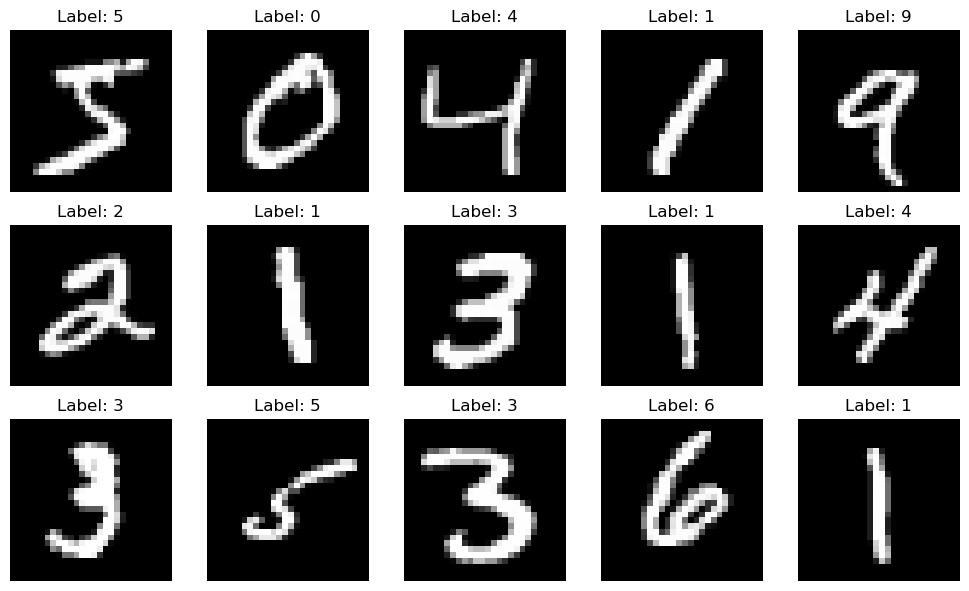

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,5, figsize=(10,6))

#enumerate

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='grey')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
#setting up model & it's parameters
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

In [14]:
#Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
#Training the model

model.fit(X_train, y_train, epochs=5, validation_split=0.1)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9096 - loss: 0.3129 - val_accuracy: 0.9597 - val_loss: 0.1368
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9559 - loss: 0.1488 - val_accuracy: 0.9728 - val_loss: 0.0957
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9661 - loss: 0.1139 - val_accuracy: 0.9767 - val_loss: 0.0797
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9720 - loss: 0.0917 - val_accuracy: 0.9800 - val_loss: 0.0717
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9758 - loss: 0.0784 - val_accuracy: 0.9782 - val_loss: 0.0692


In [17]:
#Evaluation

test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy :{test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9775 - loss: 0.0740
Test accuracy :0.978
